<a href="https://colab.research.google.com/github/AnmolChetani/pricelens-ai/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/AnmolChetani/pricelens-ai.git

Cloning into 'pricelens-ai'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 60 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 164.34 KiB | 1.34 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [3]:
%cd pricelens-ai

/content/pricelens-ai


In [4]:
!ls

app  notebooks	README.md  requirements.txt  saved_models  src


In [5]:
!git config --global user.name "AnmolChetani"
!git config --global user.email "anmolchetani@gmail.com"

In [6]:
!mkdir -p notebooks

In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Utility
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [9]:

# Use python engine + skip bad lines
train_df = pd.read_csv(
    "/content/sample_data/train.csv",
    engine='python',
    on_bad_lines='skip'
)

test_df = pd.read_csv(
    "/content/sample_data/test.csv",
    engine='python',
    on_bad_lines='skip'
)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (7531, 4)
Test shape: (7525, 3)


In [10]:
train_df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [11]:
test_df.head()

,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7531 entries, 0 to 7530
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        7531 non-null   int64  
 1   catalog_content  7531 non-null   object 
 2   image_link       7531 non-null   object 
 3   price            7531 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 235.5+ KB


In [13]:
train_df.isnull().sum()

,0
sample_id,0
catalog_content,0
image_link,0
price,0


In [14]:
test_df.isnull().sum()

,0
sample_id,0
catalog_content,0
image_link,0


In [15]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [16]:
train_df["price"].describe()

,price
count,7531.000000
mean,24.072627
std,33.068294
min,0.130000
25%,6.745000
50%,14.045000
75%,28.855000
max,613.580000


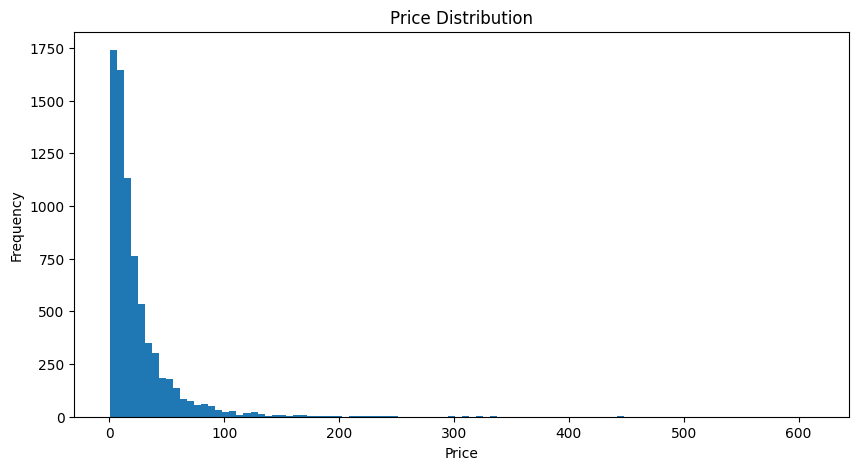

In [17]:
plt.figure(figsize=(10,5))

plt.hist(train_df["price"], bins=100)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")

plt.show()

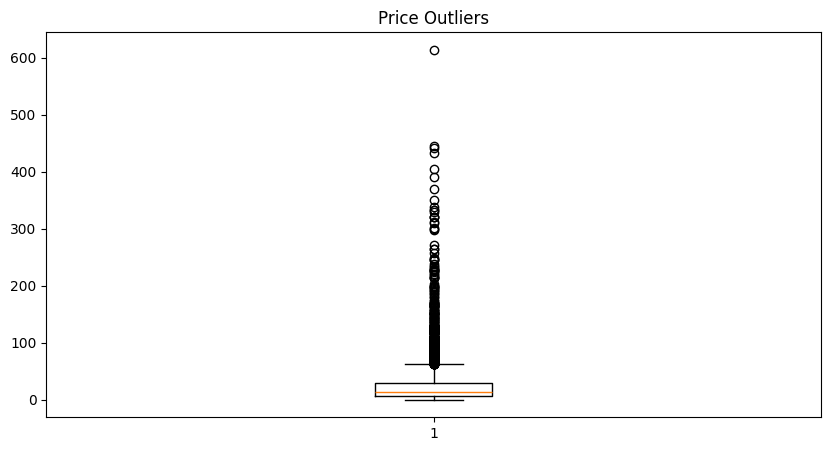

In [18]:
plt.figure(figsize=(10,5))

plt.boxplot(train_df["price"])

plt.title("Price Outliers")
plt.show()

In [19]:
for i in range(5):
    print(f"\nProduct {i+1}")
    print(train_df["catalog_content"].iloc[i])
    print("-" * 100)


Product 1
Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Value: 72.0
Unit: Fl Oz

----------------------------------------------------------------------------------------------------

Product 2
Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4)
Bullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter
Bullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total
Bullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries
Bullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family
Bullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925
Value: 32.0
Unit: Ounce

----------------------------------------------------------------------------------------------------

Product 3
Item Name: Bear Creek Hearty Soup Bowl, Creamy Chicken with Rice, 1.9 Ounce (Pack of 6)
Bullet Point 1: Loaded with hearty long grain wild rice and vegetables
Bu

In [20]:
train_df["text_length"] = train_df["catalog_content"].apply(len)

train_df["text_length"].describe()

,text_length
count,7531.000000
mean,903.483468
std,854.417231
min,37.000000
25%,249.000000
50%,639.000000
75%,1266.000000
max,6192.000000


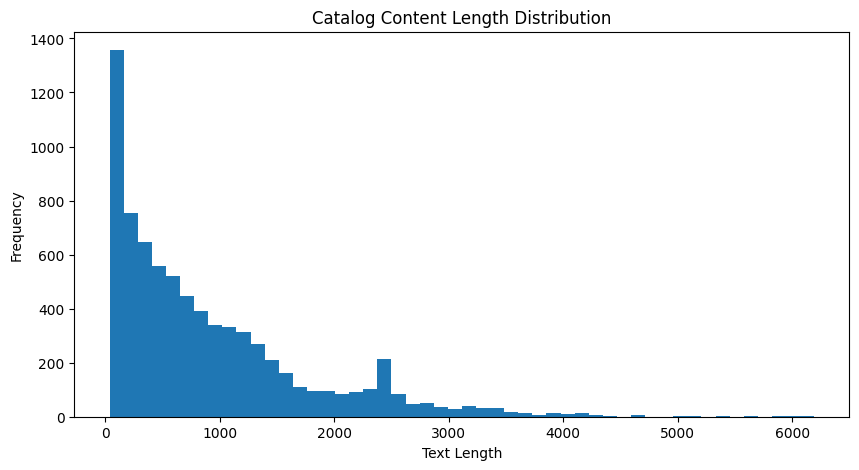

In [21]:
plt.figure(figsize=(10,5))

plt.hist(train_df["text_length"], bins=50)

plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Catalog Content Length Distribution")

plt.show()

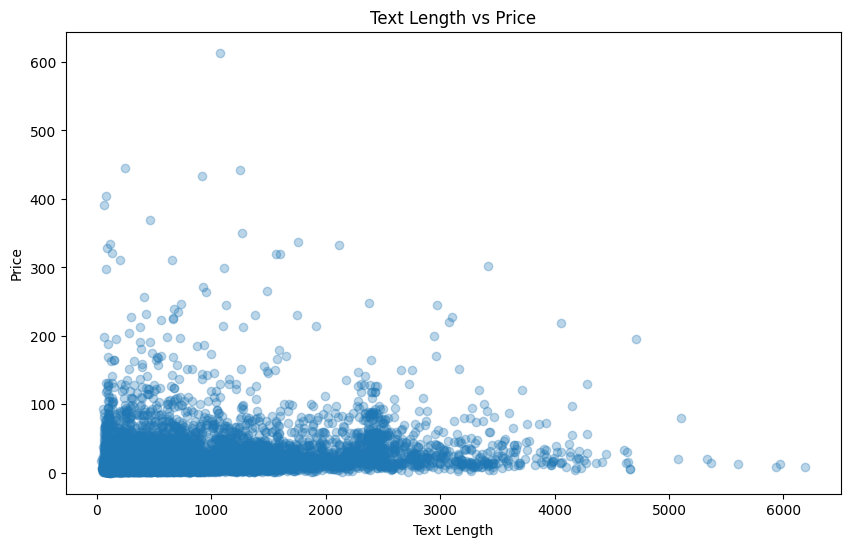

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(
    train_df["text_length"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Text Length")
plt.ylabel("Price")
plt.title("Text Length vs Price")

plt.show()

In [23]:
train_df[["text_length", "price"]].corr()

,text_length,price
text_length,1.000000,0.149698
price,0.149698,1.000000


In [24]:
import re

def extract_numbers(text):
    numbers = re.findall(r'\d+\.?\d*', text)
    return len(numbers)

train_df["num_count"] = train_df["catalog_content"].apply(extract_numbers)

train_df["num_count"].describe()

,num_count
count,7531.000000
mean,8.785951
std,5.205714
min,0.000000
25%,5.000000
50%,9.000000
75%,11.000000
max,71.000000


In [25]:
train_df[["num_count", "price"]].corr()

,num_count,price
num_count,1.000000,0.128932
price,0.128932,1.000000


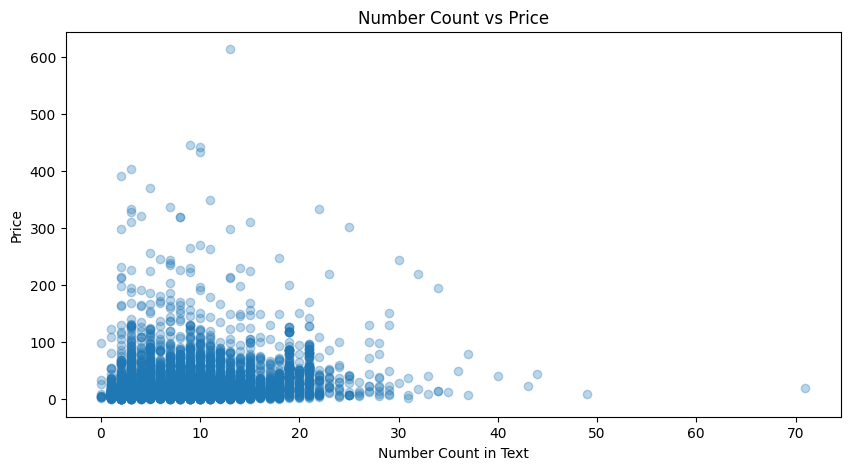

In [26]:
plt.figure(figsize=(10,5))

plt.scatter(
    train_df["num_count"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Number Count in Text")
plt.ylabel("Price")
plt.title("Number Count vs Price")

plt.show()

In [27]:
import re

def extract_pack_size(text):
    text = str(text).lower()

    match = re.search(r'pack of (\d+)', text)
    if match:
        return int(match.group(1))

    match = re.search(r'(\d+)\s*per case', text)
    if match:
        return int(match.group(1))

    return 1

train_df["pack_size"] = train_df["catalog_content"].apply(extract_pack_size)

In [28]:
train_df["pack_size"].describe()

,pack_size
count,7531.000000
mean,4.447218
std,39.335580
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,2424.000000


In [29]:
train_df["pack_size"].value_counts().head(20)

,count
pack_size,
1,5646
6,476
12,376
2,224
3,195
4,164
24,99
8,72
10,38


In [30]:
train_df[["pack_size", "price"]].corr()

,pack_size,price
pack_size,1.0000,0.0614
price,0.0614,1.0000


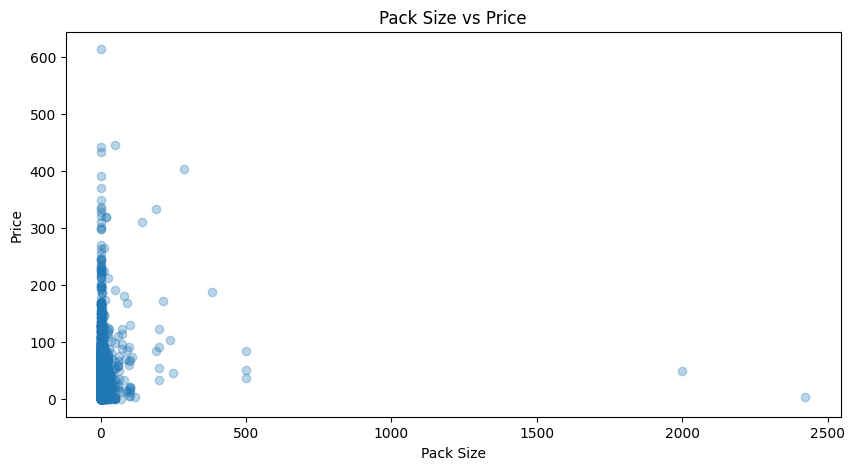

In [31]:
plt.figure(figsize=(10,5))

plt.scatter(
    train_df["pack_size"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Pack Size")
plt.ylabel("Price")
plt.title("Pack Size vs Price")

plt.show()

In [32]:
from collections import Counter
import re

# Combine all text
all_text = " ".join(train_df["catalog_content"].astype(str))

# Extract words
words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

# Remove very short words
words = [word for word in words if len(word) > 2]

# Count frequency
word_counts = Counter(words)

# Top 30 words
word_counts.most_common(30)

[('and', 33493),
 ('point', 26628),
 ('bullet', 26600),
 ('the', 23792),
 ('with', 14418),
 ('for', 14389),
 ('our', 8466),
 ('your', 8253),
 ('value', 7899),
 ('item', 7849),
 ('name', 7686),
 ('unit', 7589),
 ('tea', 7050),
 ('you', 6980),
 ('are', 6663),
 ('ounce', 6392),
 ('free', 6212),
 ('flavor', 5543),
 ('that', 5250),
 ('pack', 4496),
 ('coffee', 4479),
 ('product', 4448),
 ('taste', 3984),
 ('this', 3870),
 ('from', 3836),
 ('natural', 3611),
 ('organic', 3366),
 ('all', 3334),
 ('description', 3297),
 ('ingredients', 3266)]

In [33]:
cheap_products = train_df[
    train_df["price"] <= train_df["price"].quantile(0.25)
]

expensive_products = train_df[
    train_df["price"] >= train_df["price"].quantile(0.75)
]

print(cheap_products.shape)
print(expensive_products.shape)

(1883, 7)
(1883, 7)


In [34]:
expensive_text = " ".join(
    expensive_products["catalog_content"].astype(str)
)

expensive_words = re.findall(
    r'\b[a-zA-Z]+\b',
    expensive_text.lower()
)

expensive_words = [
    word for word in expensive_words
    if len(word) > 2
]

Counter(expensive_words).most_common(30)

[('and', 12128),
 ('the', 9215),
 ('point', 7099),
 ('bullet', 7088),
 ('with', 4672),
 ('for', 4664),
 ('tea', 3570),
 ('our', 3343),
 ('your', 2555),
 ('you', 2504),
 ('are', 2481),
 ('that', 2036),
 ('value', 2025),
 ('item', 1961),
 ('name', 1932),
 ('unit', 1894),
 ('flavor', 1748),
 ('natural', 1627),
 ('free', 1598),
 ('coffee', 1520),
 ('taste', 1500),
 ('product', 1405),
 ('water', 1402),
 ('pack', 1363),
 ('from', 1349),
 ('all', 1328),
 ('ounce', 1318),
 ('ingredients', 1248),
 ('into', 1239),
 ('this', 1226)]

In [35]:
cheap_text = " ".join(
    cheap_products["catalog_content"].astype(str)
)

cheap_words = re.findall(
    r'\b[a-zA-Z]+\b',
    cheap_text.lower()
)

cheap_words = [
    word for word in cheap_words
    if len(word) > 2
]

Counter(cheap_words).most_common(30)

[('point', 5908),
 ('bullet', 5903),
 ('and', 4377),
 ('the', 2879),
 ('with', 2331),
 ('item', 1973),
 ('value', 1947),
 ('for', 1925),
 ('unit', 1903),
 ('name', 1898),
 ('ounce', 1826),
 ('free', 1202),
 ('your', 1098),
 ('pack', 1057),
 ('you', 906),
 ('flavor', 833),
 ('our', 779),
 ('are', 716),
 ('product', 715),
 ('made', 671),
 ('that', 638),
 ('gluten', 613),
 ('this', 592),
 ('tea', 582),
 ('delicious', 561),
 ('organic', 550),
 ('taste', 522),
 ('description', 502),
 ('flavors', 499),
 ('ingredients', 499)]

In [42]:
custom_stopwords = {
    'bullet', 'point', 'item',
    'name', 'value', 'unit',
    'description', 'product',
    'and','the','with','for',
    'our','your','you','are',
    'that','from',  'all',
    'will','can','make',
    'enjoy','this','into',
    'perfect'
}

def clean_words(text):
    words = re.findall(
        r'\b[a-zA-Z]+\b',
        str(text).lower()
    )

    words = [
        word for word in words
        if len(word) > 2
        and word not in custom_stopwords
    ]

    return words

In [43]:
expensive_clean = []

for text in expensive_products["catalog_content"]:
    expensive_clean.extend(clean_words(text))

Counter(expensive_clean).most_common(30)

[('tea', 3570),
 ('flavor', 1748),
 ('natural', 1627),
 ('free', 1598),
 ('coffee', 1520),
 ('taste', 1500),
 ('water', 1402),
 ('pack', 1363),
 ('ounce', 1318),
 ('ingredients', 1248),
 ('quality', 1151),
 ('products', 1047),
 ('delicious', 988),
 ('organic', 923),
 ('chocolate', 904),
 ('terravita', 882),
 ('count', 856),
 ('pour', 829),
 ('made', 811),
 ('bags', 752),
 ('cup', 749),
 ('cold', 725),
 ('flavors', 723),
 ('certified', 721),
 ('each', 713),
 ('highest', 709),
 ('add', 700),
 ('use', 697),
 ('gluten', 686),
 ('black', 683)]

In [44]:
cheap_clean = []

for text in cheap_products["catalog_content"]:
    cheap_clean.extend(clean_words(text))

Counter(cheap_clean).most_common(30)

[('ounce', 1826),
 ('free', 1202),
 ('pack', 1057),
 ('flavor', 833),
 ('made', 671),
 ('gluten', 613),
 ('tea', 582),
 ('delicious', 561),
 ('organic', 550),
 ('taste', 522),
 ('flavors', 499),
 ('ingredients', 499),
 ('sugar', 448),
 ('mix', 443),
 ('water', 433),
 ('count', 428),
 ('chocolate', 425),
 ('snack', 422),
 ('great', 398),
 ('sauce', 359),
 ('non', 359),
 ('sweet', 358),
 ('contains', 356),
 ('natural', 344),
 ('food', 342),
 ('easy', 341),
 ('artificial', 341),
 ('quality', 330),
 ('per', 328),
 ('chicken', 327)]